In [1]:
# ===============================
# HW 2 Random Forest ML Pipeline
# i1 nerve cluster classification
# ===============================

import sys
from pathlib import Path
_cwd = Path.cwd()
_root = _cwd if (_cwd / "src").exists() else _cwd.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from src.config import (
    RAW_CSV_PATH, TRAIN_CSV_PATH, VERIFY_CSV_PATH,
    OUTPUT_DATA_DIR, FIGURES_DIR, RANDOM_STATE, LABEL_COL
)
from src.data_utils import (
    load_data, detect_label_column, basic_audit, audit_summary_table,
    split_train_verification, get_xy, save_dataframe
)
from src.metrics_utils import compute_metrics, format_metric, confusion_matrix_to_frame
from src.rf_oob import run_oob_grid, oob_results_to_dataframe, get_best_oob_model
from src.rf_cv import run_manual_3fold_cv, cv_results_to_dataframe, summarize_cv_results
from src.feature_rank import get_feature_importance_table, summarize_ground_truth_overlap
from src.runtime_test import run_verification_predictions
from src.report_helpers import (
    save_result_table_to_csv, save_top10_feature_plot,
    software_tools_text, format_audit_notes, feature_ranking_discussion_starter
)


# 1. Title and Info

**HW 2 Random Forest ML Pipeline**  
**CSC 695 / 895 Spring 2026**  
**Instructor:** D. Petkovic  
**Author:** Omeid Nadery  
**Date:** 3/13/2026  

This notebook implements a full Random Forest classification pipeline for i1 nerve cluster samples from gene expression data (CSV). It contains code, results, and written analysis in one place. The workflow includes:

1. **Audit of Original Database** — sample count, features, class balance, missing values  
2. **Creation of Training DB and Verification DB** — hold out 1× class 1 and 1× class 0  
3. **Method 1: OOB estimation** — train RF with different hyperparameters, compare accuracy  
4. **Method 2: Manual 3-fold CV** — StratifiedKFold for indices only; manual train/predict/metrics  
5. **Metrics** — confusion matrix, accuracy, precision, recall, F1 (all to 5 decimal places)  
6. **Feature ranking** — Gini importance, top 10 features, overlap with biology ground truth (COL5A2, NDNF, FAT1)  
7. **RF run-time test** — run best model on 2 held-out verification samples; show predicted class and probabilities


# 2. Audit of Original Database

Load the CSV and detect the label column (expected `label` or `Label`). Then run a full audit: sample count, feature count, class distribution, missing values, dtypes, and sanity checks.

In [2]:
# Load original data
df_original = load_data(RAW_CSV_PATH)
# Detect label column (handles "label" or "Label")
label_col = detect_label_column(df_original)
print(f"Detected label column: '{label_col}'")
print(f"Shape: {df_original.shape[0]} rows, {df_original.shape[1]} columns")

Detected label column: 'Label'
Shape: 871 rows, 609 columns


*(See audit table above for dataset summary.)*

In [3]:
# Full audit
audit = basic_audit(df_original, label_col)
audit_table = audit_summary_table(df_original, label_col)
display(audit_table)

,Audit item,Value
0,Number of samples,871
1,Number of features,608
2,Class counts,"{0: 781, 1: 90}"
3,Class percentages (%),"{0: 89.66704936854191, 1: 10.332950631458095}"
4,Missing values (total),0
5,All features numeric,True
6,PII heuristic columns found,"[PRELID2, ID2]"
7,Samples >= 10× features,False
8,Class unbalanced (<10% in any class),False


# 3. Creation of Training DB and Verification DB

Remove exactly 1 random sample with class 1 and 1 random sample with class 0 to form the verification set. The remainder is the training set.

In [4]:
train_df, verify_df = split_train_verification(df_original, label_col, random_state=RANDOM_STATE)
print(f"Training samples: {len(train_df)}, Verification samples: {len(verify_df)}")
print("Verification set class counts:", verify_df[label_col].value_counts().to_dict())

Training samples: 869, Verification samples: 2
Verification set class counts: {1: 1, 0: 1}


In [5]:
# Save processed CSVs
save_dataframe(train_df, TRAIN_CSV_PATH)
save_dataframe(verify_df, VERIFY_CSV_PATH)
print(f"Saved training DB to {TRAIN_CSV_PATH}")
print(f"Saved verification DB to {VERIFY_CSV_PATH}")

Saved training DB to C:\Users\fnshn\hw2-random-forest-i1\data\processed\training_db.csv
Saved verification DB to C:\Users\fnshn\hw2-random-forest-i1\data\processed\verification_db.csv


In [6]:
# Get X, y for training and verification
X_train, y_train = get_xy(train_df, label_col)
X_verify, y_verify = get_xy(verify_df, label_col)
feature_names = list(X_train.columns)
print(f"Training: X {X_train.shape}, y {y_train.shape}")

Training: X (869, 608), y (869,)


# 4. SW Tools

- **Python** — Runtime and scripting.
- **Jupyter Notebook** — Interactive workflow and documentation.
- **scikit-learn** — RandomForestClassifier for training, StratifiedKFold for fold indices, and metrics (confusion matrix, accuracy, precision, recall, F1).
- **pandas** — Loading CSV data, building tables, and saving outputs.
- **NumPy** — Numerical arrays and random state handling.
- **matplotlib / seaborn** — Top-10 feature importance plot (saved as reports/figures/top10_features.png).

In [7]:
print(software_tools_text())

Software: Python 3, pandas, NumPy, scikit-learn (RandomForestClassifier, StratifiedKFold), matplotlib, seaborn. Environment: Jupyter Notebook or Python script.


# 5. Experimental Methods and Setup

**Method 1, Random Forest with OOB estimation.** Out-of-bag (OOB) estimation uses the fact that each tree in the forest is trained on a bootstrap sample of the data, so about one-third of the training samples are OOB for each tree. Those samples get predictions from the trees that did not use them, giving an internal validation estimate without a separate holdout set. A grid search was run over n_estimators (200, 500, 1000), max_features (mtry: sqrt, 2×sqrt ≈ 49, 5×sqrt ≈ 123, and 0.1 as fraction), and min_samples_leaf (1, 2, 5). Each model used RandomForestClassifier with bootstrap=True and oob_score=True. OOB predictions were taken from the out-of-bag decision function and thresholded at 0.5. The best model was chosen by highest F1 because the dataset is imbalanced (few i1 samples); F1 balances precision and recall.

**Method 2, Manual 3-fold cross-validation.** This method gives an estimate of how the model generalizes by training on two-thirds of the data and evaluating on the remaining third, repeated three times so each sample is in the test set exactly once. StratifiedKFold was used only to get train and test indices (no one-line CV shortcut). For each fold, a separate RandomForestClassifier was trained and predictions were made on the test indices. The same hyperparameters as the best OOB model were used so that the CV results are comparable.

# 6. Actual Results of RF Training and Accuracy Estimates

## Method 1: OOB estimation

Train multiple RF models with different hyperparameters; evaluate using OOB predictions. All accuracies shown to 5 decimal places.

In [8]:
oob_results = run_oob_grid(X_train, y_train, random_state=RANDOM_STATE)
oob_df = oob_results_to_dataframe(oob_results)
# Format accuracy to 5 decimal places for display
oob_display = oob_df.copy()
for col in ["oob_score", "accuracy", "precision", "recall", "f1"]:
    if col in oob_display.columns:
        oob_display[col] = oob_display[col].apply(lambda x: format_metric(x))
display(oob_display)

,n_estimators,max_features,min_samples_leaf,oob_score,accuracy,precision,recall,f1
0,200,sqrt,1,0.98619,0.98619,1.00000,0.86517,0.92771
1,200,sqrt,2,0.98159,0.98159,0.98667,0.83146,0.90244
2,200,sqrt,5,0.98044,0.98044,1.00000,0.80899,0.89441
3,200,49,1,0.98389,0.98504,0.98718,0.86517,0.92216
4,200,49,2,0.98389,0.98389,0.98701,0.85393,0.91566
5,200,49,5,0.98504,0.98504,0.98718,0.86517,0.92216
6,200,123,1,0.98274,0.98274,0.97436,0.85393,0.91018
7,200,123,2,0.98504,0.98504,0.98718,0.86517,0.92216
8,200,123,5,0.98504,0.98504,0.98718,0.86517,0.92216
9,200,0.1,1,0.98619,0.98619,0.98734,0.87640,0.92857


In [9]:
# Best model by F1
best_oob = get_best_oob_model(oob_results, sort_by="f1")
best_model = best_oob["model"]
print("Best OOB config: n_estimators={}, max_features={}, min_samples_leaf={}".format(
    best_oob["n_estimators"], best_oob["max_features"], best_oob["min_samples_leaf"]))
print("Best OOB accuracy: {}".format(format_metric(best_oob["accuracy"])))
print("Best OOB F1: {}".format(format_metric(best_oob["f1"])))
print("Confusion matrix (OOB):")
print(confusion_matrix_to_frame(best_oob["confusion_matrix"]))

Best OOB config: n_estimators=1000, max_features=123, min_samples_leaf=1
Best OOB accuracy: 0.98734
Best OOB F1: 0.93491
Confusion matrix (OOB):
     0   1
0  779   1
1   10  79


## Method 2: Manual 3-fold cross-validation

Using the best hyperparameters from OOB, run manual 3-fold CV (StratifiedKFold for indices only; manual train/predict/metrics per fold). Report per-fold and mean metrics to 5 decimal places.

In [10]:
cv_results = run_manual_3fold_cv(
    X_train, y_train,
    n_estimators=best_oob["n_estimators"],
    max_features=best_oob["max_features"],
    min_samples_leaf=best_oob["min_samples_leaf"],
    random_state=RANDOM_STATE
)
cv_df = cv_results_to_dataframe(cv_results)
cv_display = cv_df.copy()
for col in ["accuracy", "precision", "recall", "f1"]:
    cv_display[col] = cv_display[col].apply(lambda x: format_metric(x))
display(cv_display)

,fold,train_class_0,train_class_1,test_class_0,test_class_1,accuracy,precision,recall,f1
0,1,520,59,260,30,0.97931,1.00000,0.80000,0.88889
1,2,520,59,260,30,0.98621,0.96429,0.90000,0.93103
2,3,520,60,260,29,0.98962,1.00000,0.89655,0.94545


In [11]:
cv_summary = summarize_cv_results(cv_results)
print("CV mean accuracy:", format_metric(cv_summary["mean_accuracy"]))
print("CV mean precision:", format_metric(cv_summary["mean_precision"]))
print("CV mean recall:", format_metric(cv_summary["mean_recall"]))
print("CV mean F1:", format_metric(cv_summary["mean_f1"]))

CV mean accuracy: 0.98505
CV mean precision: 0.98810
CV mean recall: 0.86552
CV mean F1: 0.92179


# 7. Feature Ranking

Use Gini feature importance from the best trained Random Forest. Print and save the top 10 ranked features. Check overlap with biology ground truth (COL5A2, NDNF, FAT1; COL5A2 family by prefix).

In [12]:
importance_df = get_feature_importance_table(best_model, feature_names)
importance_df["rank"] = range(1, len(importance_df) + 1)
top10 = importance_df.head(10)[["rank", "feature", "gini_importance"]]
# Show with 5 decimal places for importance
top10_display = top10.copy()
top10_display["gini_importance"] = top10_display["gini_importance"].apply(lambda x: format_metric(x))
print("Top 10 ranked features (Gini importance):")
display(top10_display)

Top 10 ranked features (Gini importance):


,rank,feature,gini_importance
0,1,COL5A2.1,0.12725
1,2,COL5A2.2,0.12706
2,3,COL5A2,0.11970
3,4,NDNF.2,0.04422
4,5,MYO16,0.03574
5,6,NDNF.1,0.03569
6,7,NDNF,0.03266
7,8,FAT1,0.03151
8,9,NPNT,0.02999
9,10,CBLN4,0.02176


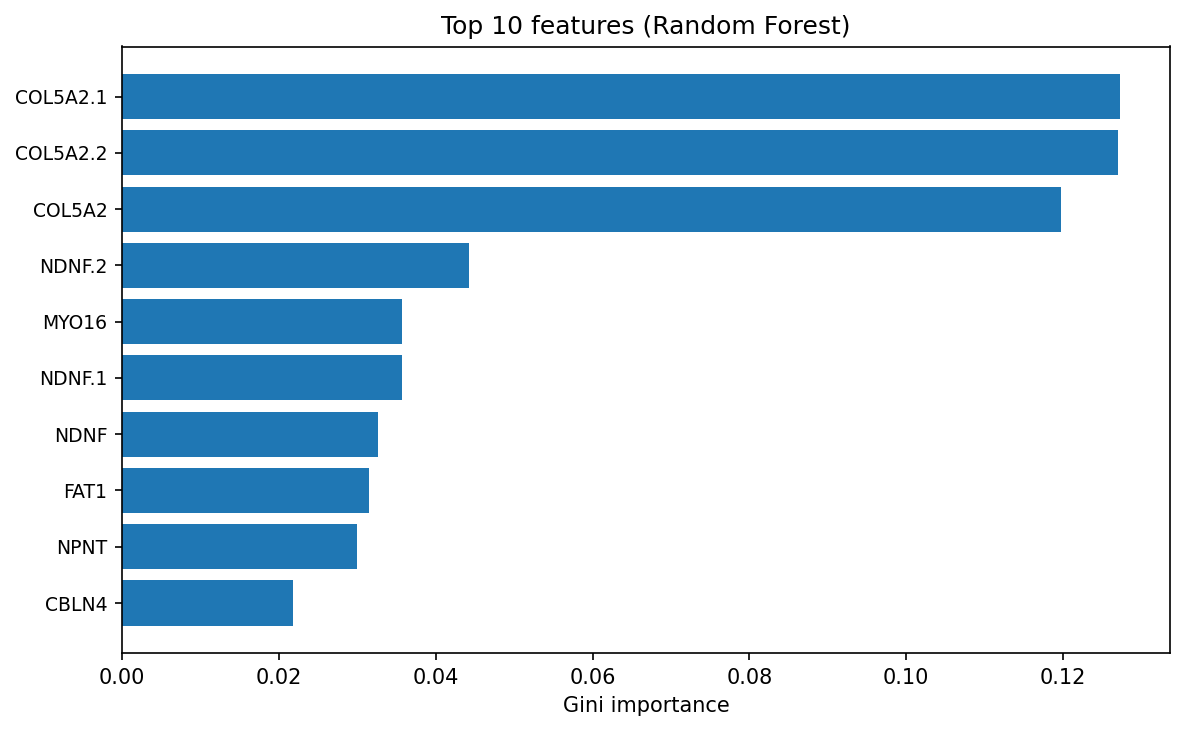

In [13]:
# Save and display the top 10 feature importance plot (also saved again in Save outputs section)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
save_top10_feature_plot(importance_df, FIGURES_DIR / "top10_features.png")
from IPython.display import Image, display
display(Image(filename=str(FIGURES_DIR / "top10_features.png")))

In [14]:
overlap = summarize_ground_truth_overlap(importance_df, top_n=10)
print("Ground truth overlap (COL5A2, NDNF, FAT1 in top 10):")
print(overlap["summary"])
print("\nDiscussion starter:")
print(feature_ranking_discussion_starter(overlap))

Ground truth overlap (COL5A2, NDNF, FAT1 in top 10):
COL5A2 family (prefix): COL5A2.1, COL5A2.2, COL5A2; NDNF: NDNF.2, NDNF.1, NDNF; FAT1: FAT1

Discussion starter:
Feature ranking (Gini importance) from the best Random Forest model. Biology ground truth for i1 cluster involves COL5A2, NDNF, and FAT1; COL5A2 family genes (e.g. COL5A2, COL5A2.1) are considered together. Overlap with top 10: COL5A2 family (prefix): COL5A2.1, COL5A2.2, COL5A2; NDNF: NDNF.2, NDNF.1, NDNF; FAT1: FAT1


# 8. RF Run Time Test — Verification Samples


In [15]:
verify_pred_df = run_verification_predictions(best_model, X_verify, y_verify)
verify_pred_display = verify_pred_df.copy()
verify_pred_display["prob_class_0"] = verify_pred_display["prob_class_0"].apply(lambda x: format_metric(x))
verify_pred_display["prob_class_1"] = verify_pred_display["prob_class_1"].apply(lambda x: format_metric(x))
print("Predictions on 2 held-out verification samples:")
display(verify_pred_display)

Predictions on 2 held-out verification samples:


,true_class,predicted_class,prob_class_0,prob_class_1,correct
0,1,1,0.03100,0.96900,True
1,0,0,0.74000,0.26000,True


# Save outputs to CSV and figures

Save result tables and top 10 feature plot to the outputs directory.

In [16]:
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

save_result_table_to_csv(oob_df, "oob_results.csv")
save_result_table_to_csv(cv_df, "cv_fold_results.csv")
save_result_table_to_csv(importance_df.head(10), "top10_features.csv")
save_result_table_to_csv(verify_pred_df, "verification_predictions.csv")
save_top10_feature_plot(importance_df, FIGURES_DIR / "top10_features.png")

print("Saved: oob_results.csv, cv_fold_results.csv, top10_features.csv, verification_predictions.csv")
print("Saved figure: reports/figures/top10_features.png")

Saved: oob_results.csv, cv_fold_results.csv, top10_features.csv, verification_predictions.csv
Saved figure: reports/figures/top10_features.png


# References

- Aevermann et al. (2018). Cell type discovery using single-cell transcriptomics: implications for ontological representation. Human Molecular Genetics.
- Scikit-learn documentation. https://scikit-learn.org/
- ChatGPT was used to generate the report structure and instructions for this assignment.

# 9. Resources

- **Data:** `data/raw/Original training DB i1 cluster.csv`
- **Processed:** `data/processed/training_db.csv`, `data/processed/verification_db.csv`
- **Outputs:** `data/outputs/` (CSVs), `reports/figures/` (PNG)
- **Code:** `src/` (config, data_utils, metrics_utils, rf_oob, rf_cv, feature_rank, runtime_test, report_helpers)
- **Notebook:** This file — run from project root so `src` imports work.